# F_photometry_tuning_psth.ipynb

## Purpose

Computes tuning curves and PSTHs for fiber photometry signals by binning the signal into 6 prediction error (PE) levels aligned to choice time. Reveals how the PrL photometry signal scales as a function of reward prediction error.

## Manuscript figure panels

- Fig5i-k
- Fig6i-l
- FigA17

## Prerequisites

Before running this notebook, ensure the figure preparation scripts have been run in sequence (see `/root/capsule/code/beh_ephys_analysis/session_combine/figure_preparation/sequence`).

Required input files:
- Photometry GLM results (Step 11)
- Per-session photometry data

In [1]:
import numpy as np
import pandas as pd
import sys
from pathlib import Path
# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
import os
import pathlib

# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
try:
    _here = pathlib.Path(__file__).resolve().parent          # script mode
except NameError:
    try:
        _here = pathlib.Path(__vsc_ipynb_file__).resolve().parent  # VS Code notebook
    except NameError:
        _here = pathlib.Path(os.getcwd())                    # other Jupyter fallback

_beh_ephys_root = str((_here / '../..').resolve())
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)
from utils.ephys_functions import fitSpikeModelG
import platform
import shutil
from utils.beh_functions import session_dirs, get_session_tbl, makeSessionDF
from utils.photometry_utils import get_FP_data, align_signal_to_events
from utils.capsule_migration import capsule_directories
from matplotlib import pyplot as plt
from IPython.display import display
from scipy.signal import find_peaks
from harp.clock import align_timestamps_to_anchor_points
from scipy.signal import butter, filtfilt, medfilt, sosfiltfilt
from scipy.optimize import curve_fit
import json
from sklearn.linear_model import LinearRegression
from matplotlib.gridspec import GridSpec
import pickle
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time

# %matplotlib widget
import re
import random
from utils.photometry_combine import population_GLM, plot_tuning_curve, plot_psth, population_GLM_ani
from contextlib import redirect_stdout
capsule_dirs = capsule_directories()
%matplotlib inline
from utils.capsule_migration import CAPSULE_ROOT
from scipy.stats import zscore
from utils.panel_utils import save_panels, save_panel_csv, columns_to_df, heatmap_to_df


In [3]:
session_csv = CAPSULE_ROOT + '/code/data_management/hopkins_FP_session_assets.csv'
session_tbl = pd.read_csv(session_csv)
session_list = session_tbl['session_id'].tolist()
target_folder = f'{capsule_dirs["manuscript_fig_dir"]}/F_photometry'
save_dir = os.path.join(target_folder, 'tuning&psth')
source_folder = f'{capsule_dirs["manuscript_fig_prep_dir"]}/photometry_regressions'

## Prediction Error Tuning Curve Analysis

Generate population-level tuning curves showing how photometry signals in the prelimbic cortex (PL) vary as a function of prediction error. This analysis bins trials into 6 PE levels and computes the average signal aligned to choice time, revealing whether PL activity tracks reward prediction errors in a graded manner.

Processing tuning curve for region: PL, channel: G_tri-exp_mc, align: choice_time, num_bins: 6, threshold: 0.5


Saved results to /root/capsule/scratch/results/manuscript/figures/F_photometry/tuning&psth/population_tuning_curve_pe_PL_G_tri-exp_mc_choice_time_numbins6_thresg0.5_quantilesFalse.pkl


['/root/capsule/scratch/results/manuscript/figures/F_photometry/tuning&psth/Figure6l_population_tuning_curve_pe_PL_G_tri-exp_mc_choice_time_numbins6_thresg0.5_quantilesFalse.csv']

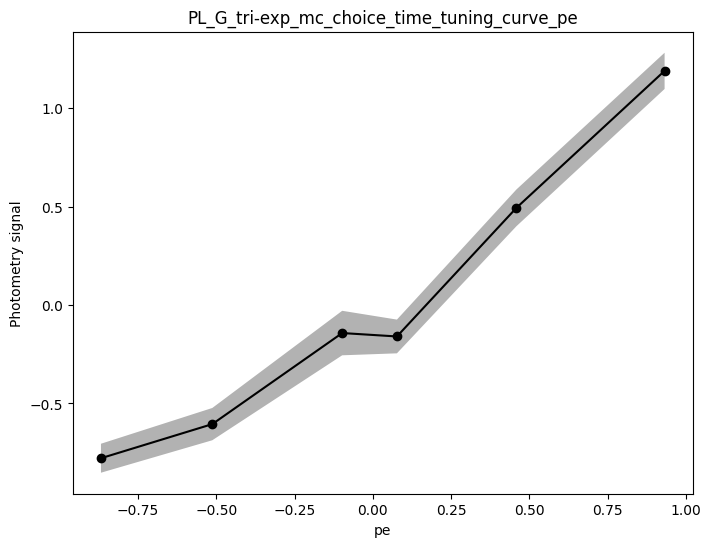

In [3]:
region_curr = 'PL'
channel_curr = 'G_tri-exp_mc'
align_curr = 'choice_time'
num_bins = 6
thresh_curr = 0.5
quantiles = False
pre_time = -0.2
post_time = 2.2

params_dict = {
    'region_curr': region_curr,
    'channel_curr': channel_curr,
    'align_curr': align_curr,
    'num_bins': num_bins,
    'thresh_curr': thresh_curr,
    'quantiles': quantiles,
    'pre_time': pre_time,
    'post_time': post_time
}
print(f'Processing tuning curve for region: {region_curr}, channel: {channel_curr}, align: {align_curr}, num_bins: {num_bins}, threshold: {thresh_curr}')

results = plot_tuning_curve(
    session_list, region=region_curr, target_var = 'pe', channel= channel_curr, 
    align=align_curr, pre_time=pre_time, post_time=post_time, num_bins=num_bins, thresh=thresh_curr, quantiles=quantiles
)

save_dir = os.path.join(target_folder, 'tuning&psth')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
file_name = f'population_tuning_curve_pe_{region_curr}_{channel_curr}_{align_curr}_numbins{num_bins}_thresg{thresh_curr}_quantiles{quantiles}.pkl'
with open(os.path.join(save_dir, file_name), 'wb') as f:
    pickle.dump(results, f)
    pickle.dump(params_dict, f)
print(f'Saved results to {os.path.join(save_dir, file_name)}')
# save fig
save_panels(results['fig'], save_dir, file_name.replace('.pkl', ''), ['Figure6l'], exts=('pdf',), dpi=300)
# ---- panel CSV (rule 5: 1D errorbar, tuning curve; x=RPE bin, one column per session) ----
_bx = np.nanmean(np.asarray(results['bin_means']), 0); _sig = np.asarray(results['signal_means'])
_c = {'rpe_bin': _bx}
for _s in range(_sig.shape[0]):
    _c[f'session_{_s}'] = _sig[_s]
save_panel_csv(columns_to_df(**_c), save_dir, file_name.replace('.pkl', ''), ['Figure6l'])
##Figure6l##

## Prediction Error PSTH Analysis

Compute peri-stimulus time histograms (PSTHs) for photometry signals binned by prediction error level. This provides a temporal profile of how PL signals evolve around choice time for different levels of prediction error, complementing the static tuning curve analysis above.

Processing session behavior_669489_2023-06-27_14-20-19 for tuning curve...
Processing session behavior_669489_2023-07-07_15-15-49 for tuning curve...
Processing session behavior_669492_2023-06-29_18-28-17 for tuning curve...
Processing session behavior_669492_2023-07-05_18-51-39 for tuning curve...
Processing session behavior_672850_2023-06-28_17-35-53 for tuning curve...
Processing session behavior_672850_2023-07-06_18-10-32 for tuning curve...
Processing session behavior_699461_2023-12-20_09-12-11 for tuning curve...
Processing session behavior_699461_2024-01-17_08-56-16 for tuning curve...
Processing session behavior_699462_2024-01-17_10-36-54 for tuning curve...
Processing session behavior_699472_2024-01-06_14-52-56 for tuning curve...
Processing session behavior_699472_2024-01-14_16-58-42 for tuning curve...
Processing session behavior_701707_2024-01-05_14-41-22 for tuning curve...
Processing session behavior_749472_2024-12-30_14-44-06 for tuning curve...
Processing session behavi

['/root/capsule/scratch/results/manuscript/figures/F_photometry/tuning&psth/Figure6i_population_psth_pe_PL_G_tri-exp_mc_choice_time_numbins6_thresg0.5_quantilesFalse.csv']

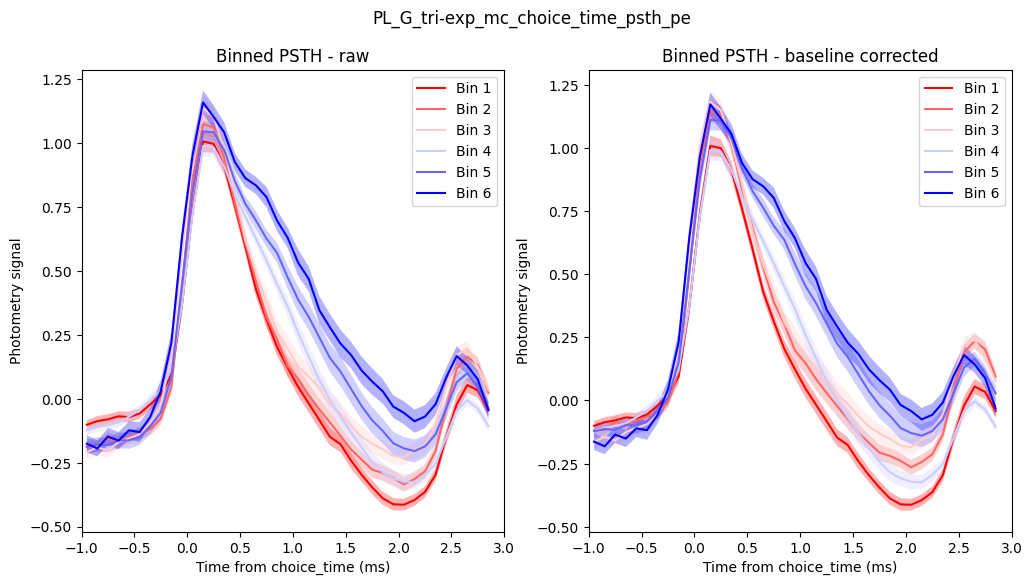

In [4]:
region_curr = 'PL'
channel_curr = 'G_tri-exp_mc'
align_curr = 'choice_time'
pre_time = 1
post_time = 3
num_bins = 6
thresh_curr = 0.5
quantiles = False

params_dict = {
    'region_curr': region_curr,
    'channel_curr': channel_curr,
    'align_curr': align_curr,
    'num_bins': num_bins,
    'thresh_curr': thresh_curr,
    'quantiles': quantiles,
    'pre_time': pre_time,
    'post_time': post_time
}
results = plot_psth(
    session_list, region=region_curr, target_var = 'pe', channel= channel_curr, 
    align=align_curr, pre_time=pre_time, post_time=post_time, num_bins=num_bins, thresh=thresh_curr, quantiles=quantiles
);
file_name = f'population_psth_pe_{region_curr}_{channel_curr}_{align_curr}_numbins{num_bins}_thresg{thresh_curr}_quantiles{quantiles}.pkl'
with open(os.path.join(save_dir, file_name), 'wb') as f:
    pickle.dump(results, f)
    pickle.dump(params_dict, f)
save_panels(results['fig'], save_dir, file_name.replace('.pkl', ''), ['Figure6i'], exts=('pdf',), dpi=300)
# ---- panel CSV (rule 2: filled psth, per-bin mean+/-sem across sessions) ----
_bp = np.asarray(results['binned_psth']); _t = np.asarray(results['time_bins'])
_mean = np.nanmean(_bp, 0); _sem = np.nanstd(_bp, 0) / np.sqrt(np.sum(~np.isnan(_bp), 0))
_c = {'time_s': _t}
for _b in range(_mean.shape[0]):
    _c[f'bin_{_b + 1}_mean'] = _mean[_b]; _c[f'bin_{_b + 1}_sem'] = _sem[_b]
save_panel_csv(columns_to_df(**_c), save_dir, file_name.replace('.pkl', ''), ['Figure6i'])
##Figure6i##

## Switch vs Stay Behavior Analysis

Analyze photometry signals during switch versus stay trials aligned to the go cue. This analysis examines whether PL signals differ when animals switch their choice pattern versus when they maintain their previous choice, revealing potential involvement in behavioral flexibility.

['/root/capsule/scratch/results/manuscript/figures/F_photometry/tuning&psth/Figure5j_population_psth_by_hit_PL_G_tri-exp_mc_goCue_start_time_numbins2_thresg0.5_quantilesFalse.csv']

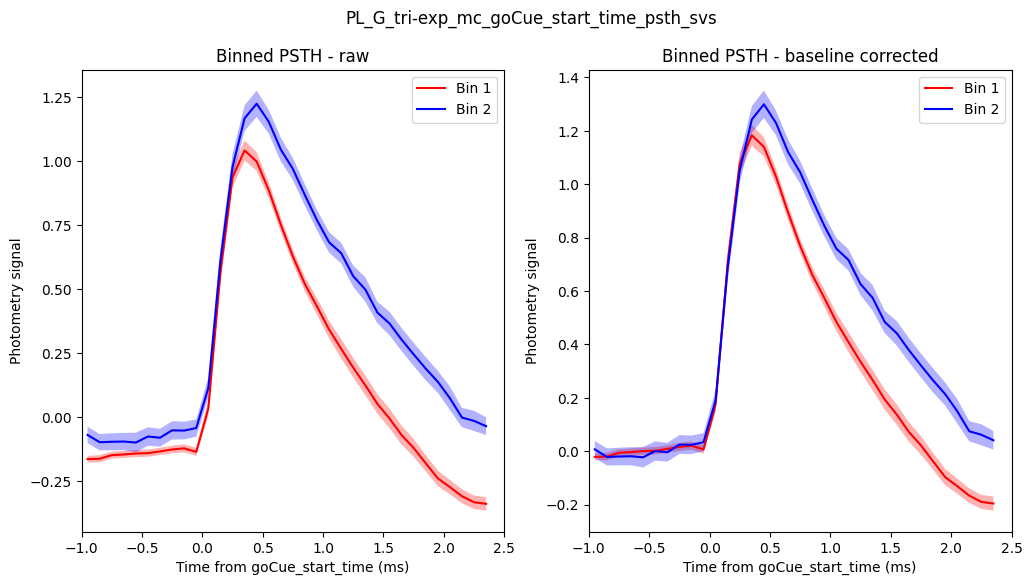

In [ ]:
region_curr = 'PL'
channel_curr = 'G_tri-exp_mc'
align_curr = 'goCue_start_time'
pre_time = 1.0
post_time = 2.5
num_bins = 2
thresh_curr = 0.5
quantiles = False
results = plot_psth(
    session_list, region=region_curr, target_var = 'svs', channel= channel_curr, 
    align=align_curr, pre_time=pre_time, post_time=post_time, num_bins=num_bins, thresh=thresh_curr, quantiles=quantiles
);
file_name = f'population_psth_by_switch_vs_stay_{region_curr}_{channel_curr}_{align_curr}_0_stay_1_switch.pkl'
save_panels(results['fig'], save_dir, file_name.replace('.pkl', ''), ['Figure5j'], exts=('pdf',), dpi=300)
# ---- panel CSV (rule 2: filled psth, per-bin mean+/-sem across sessions) ----
_bp = np.asarray(results['binned_psth']); _t = np.asarray(results['time_bins'])
_mean = np.nanmean(_bp, 0); _sem = np.nanstd(_bp, 0) / np.sqrt(np.sum(~np.isnan(_bp), 0))
_c = {'time_s': _t}
for _b in range(_mean.shape[0]):
    _c[f'bin_{_b + 1}_mean'] = _mean[_b]; _c[f'bin_{_b + 1}_sem'] = _sem[_b]
save_panel_csv(columns_to_df(**_c), save_dir, file_name.replace('.pkl', ''), ['Figure5j'])
##Figure5j##

## Hit vs Miss Performance Analysis

Compare photometry signals between hit and miss trials aligned to the go cue onset. This analysis tests whether PL activity predicts or reflects successful task performance by examining signal differences between trials with correct versus incorrect outcomes.

['/root/capsule/scratch/results/manuscript/figures/F_photometry/tuning&psth/FigureS17h_right_population_psth_by_hit_PL_G_tri-exp_mc_goCue_start_time_numbins2_thresg0.5_quantilesFalse.csv']

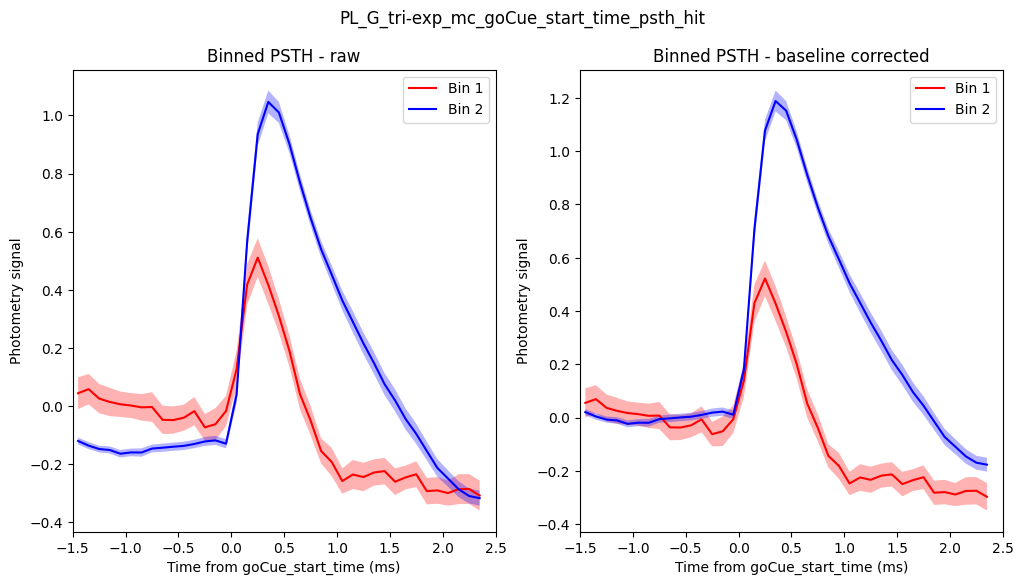

In [6]:
region_curr = 'PL'
channel_curr = 'G_tri-exp_mc'
align_curr = 'goCue_start_time'
pre_time = 1.5
post_time = 2.5
num_bins = 2
thresh_curr = 0.5
quantiles = False
results = plot_psth(
    session_list, region=region_curr, target_var = 'hit', channel= channel_curr, 
    align=align_curr, pre_time=pre_time, post_time=post_time, num_bins=num_bins, thresh=thresh_curr, quantiles=quantiles
);
file_name = f'population_psth_by_hit_{region_curr}_{channel_curr}_{align_curr}_numbins{num_bins}_thresg{thresh_curr}_quantiles{quantiles}.pkl'
save_panels(results['fig'], save_dir, file_name.replace('.pkl', ''), ['FigureS17h_right'], exts=('pdf',), dpi=300)
# ---- panel CSV (rule 2: filled psth, per-bin mean+/-sem across sessions) ----
_bp = np.asarray(results['binned_psth']); _t = np.asarray(results['time_bins'])
_mean = np.nanmean(_bp, 0);  _sem = np.nanstd(_bp, 0) / np.sqrt(np.sum(~np.isnan(_bp), 0))
_c = {'time_s': _t}
for _b in range(_mean.shape[0]):
    _c[f'bin_{_b + 1}_mean'] = _mean[_b]; _c[f'bin_{_b + 1}_sem'] = _sem[_b]
save_panel_csv(columns_to_df(**_c), save_dir, file_name.replace('.pkl', ''), ['FigureS17h_right'])
##FigureS17h_right##

In [7]:
results['binned_psth'].shape

(67, 2, 39)

In [8]:
results['time_bins'].shape

(39,)

## GLM Coefficient Analysis Setup

Load and analyze GLM regression results from session-wise and animal-wise models. These models regress photometry signals against behavioral variables (outcome, Q-value) to quantify the relationship between neural activity and task parameters.

In [9]:
# plot scatter and polar histogram of glm weights
save_dir = os.path.join(target_folder, 'photometry_regressions')
session_file_name = 'population_GLM_session-wise_PL_G_tri-exp_mc_choice_time_win2_thresh0.5_formula_1_outcomexipsi_Qchosen_iso.pkl'
ani_file_name = 'population_GLM_animal-wise_PL_G_tri-exp_mc_choice_time_win2_thresh0.5_formula_1_outcomexipsi_Qchosen_iso.pkl'
with open(os.path.join(source_folder, session_file_name), 'rb') as f:
    params_dict = pickle.load(f)
    results = pickle.load(f)
with open(os.path.join(source_folder, ani_file_name), 'rb') as f:
    ani_params_dict = pickle.load(f)
    ani_results = pickle.load(f)
plt.close('all')

In [10]:
time_bins = results['time_bins']
target_start = 0.7
target_start_ind = np.where(time_bins >= target_start)[0][0]
time_bins[target_start_ind]

np.float64(0.7000000000000002)

In [11]:
ani_list = [session_dirs(session)['aniID'] for session in results['session_list']]
uni_ani = np.unique(ani_list)

## GLM Coefficient Space Visualization

Visualize the relationship between outcome and Q-value encoding in a 2D coefficient space. The scatter plot shows individual session GLM T-statistics with animal-level means overlaid, while the polar histogram reveals the angular distribution of encoding directions, showing whether sessions preferentially encode outcome, Q-value, or a mixture of both.

Animal 669492: indices 15
Animal 699462: indices 12


Animal 699472: indices 11
Animal 749472: indices 9


Animal 749624: indices 5
Animal 754896: indices 7


Animal 754898: indices 8


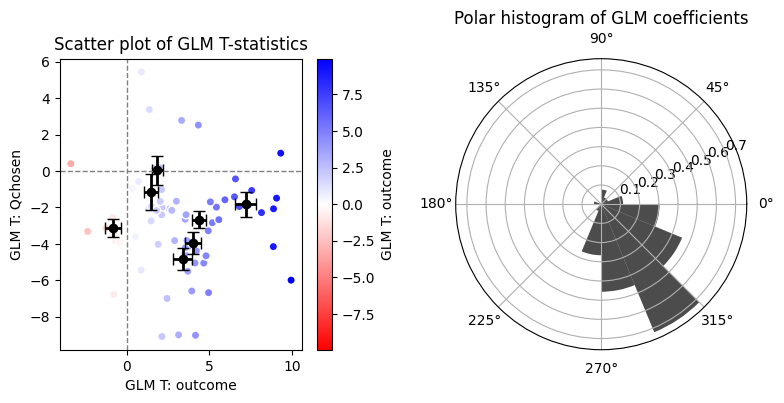

In [13]:
from matplotlib.gridspec import GridSpec
# custom colormap red white blue
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    'red_white_blue',
    ['red', 'white', 'blue']
)


# --- indices ---
regressors = list(results['regressors'])
outcome_ind = regressors.index('outcome')
q_ind = regressors.index('Qchosen')

# --- extract T-stats ---
T_outcome = results['tstats'][:, target_start_ind, outcome_ind]
T_q = results['tstats'][:, target_start_ind, q_ind]

# --- extract coefficients ---
coef_outcome = results['coefs'][:, target_start_ind, outcome_ind]
coef_q = results['coefs'][:, target_start_ind, q_ind]

# --- vectors ---
all_vec = np.column_stack((coef_outcome, coef_q))

# Cartesian → polar
theta = np.arctan2(all_vec[:, 1], all_vec[:, 0])   # y, x (standard convention)
rho = np.hypot(all_vec[:, 0], all_vec[:, 1])

# --- figure ---
fig = plt.figure(figsize=(8, 4))
gs = GridSpec(1, 2, figure=fig)

# ===== Scatter plot =====
ax_scatter = fig.add_subplot(gs[0, 0])
sc = ax_scatter.scatter(
    T_outcome,
    T_q,
    c=T_outcome,
    alpha=1,
    edgecolors=[1, 1, 1],
    cmap=custom_cmap,
    norm=plt.Normalize(vmin=min(-np.abs(T_outcome)), vmax=max(np.abs(T_outcome)))
)

# scatter plot mean T values for each animal's sessions and error bars as standard error
for ani_ind, ani in enumerate(ani_results['ani_list']):
    ani_inds = [i for i, x in enumerate(results['session_list']) if session_dirs(x)['aniID'] == ani]
    print(f'Animal {ani}: indices {len(ani_inds)}')
    ani_T_outcome = T_outcome[ani_inds]
    ani_T_q = T_q[ani_inds]
    ani_T_outcome_1_model = ani_results['tstats'][ani_ind, target_start_ind, ani_results['regressors'].index('outcome')]
    ani_T_q_1_model = ani_results['tstats'][ani_ind, target_start_ind, ani_results['regressors'].index('Qchosen')]
    ax_scatter.errorbar(
        np.mean(ani_T_outcome),
        np.mean(ani_T_q),
        xerr=np.std(ani_T_outcome) / np.sqrt(len(ani_T_outcome)),
        yerr=np.std(ani_T_q) / np.sqrt(len(ani_T_q)),
        fmt='o',
        color='black',
        ecolor='black',
        elinewidth=2,
        capsize=4,
        markersize=6
    )
    
ax_scatter.set_xlabel('GLM T: outcome')
ax_scatter.set_ylabel('GLM T: Qchosen')
ax_scatter.axhline(0, color='gray', linestyle='--', lw=1)
ax_scatter.axvline(0, color='gray', linestyle='--', lw=1)
ax_scatter.set_title('Scatter plot of GLM T-statistics')

plt.colorbar(sc, ax=ax_scatter, label='GLM T: outcome')

# ===== Polar histogram =====
edges = np.linspace(-np.pi, np.pi, 17)  # 16 bins

ax_polar = fig.add_subplot(gs[0, 1], polar=True)
ax_polar.hist(
    theta,
    bins=edges,
    color='k',
    alpha=0.7,
    density=True
)
ax_polar.set_title('Polar histogram of GLM coefficients')

plt.tight_layout()

if not os.path.exists(save_dir):
    os.makedirs(save_dir)
save_panels(fig, save_dir, f'scatter_polar_histogram_start_{target_start}_from_{session_file_name.split(".pkl")[0]}', ['Figure6k', 'Figure6j'], exts=('pdf',))
# ---- panel CSVs (rule 9: Figure6j=scatter, Figure6k=polar histogram) ----
save_panel_csv(columns_to_df(T_outcome=T_outcome, T_q=T_q), save_dir, f'scatter_polar_histogram_start_{target_start}_from_{session_file_name.split(".pkl")[0]}', ['Figure6j'], plot_type='scatter')
save_panel_csv(columns_to_df(theta_rad=theta, rho=rho), save_dir, f'scatter_polar_histogram_start_{target_start}_from_{session_file_name.split(".pkl")[0]}', ['Figure6k'], plot_type='polar_histogram')
plt.show()
##Figure6k##
##Figure6j##


## Export Angular Encoding Parameters

Save the angular encoding parameters (theta) derived from GLM coefficients for downstream analysis. These values quantify each session's position in the outcome-Q encoding space.

In [14]:
# save theta, to be called by other functions
theta_df = pd.DataFrame({'theta': theta})
curr_save_dr = os.path.join(target_folder, 'compare_params')
if not os.path.exists(curr_save_dr):
    os.makedirs(curr_save_dr)
theta_df.to_csv(os.path.join(curr_save_dr, f'glm_coeff_theta_start_{target_start}.csv'), index=False)

## Alternative Coefficient Visualization

Generate an alternative visualization of GLM coefficients (rather than T-statistics) with confidence intervals from animal-wise models. This provides effect size information rather than just statistical significance, showing the magnitude of outcome and Q-value encoding.

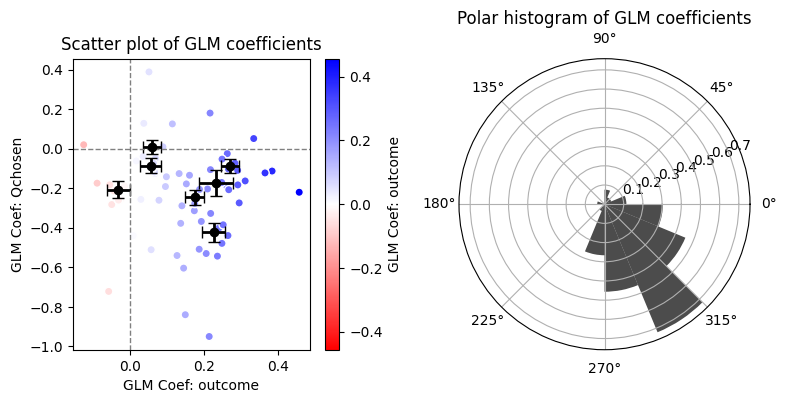

In [15]:
# plot another version of coeffs

custom_cmap = LinearSegmentedColormap.from_list(
    'red_white_blue',
    ['red', 'white', 'blue']
)


# --- indices ---
regressors = list(results['regressors'])
outcome_ind = regressors.index('outcome')
q_ind = regressors.index('Qchosen')

# --- extract coefficients ---
coef_outcome = results['coefs'][:, target_start_ind, outcome_ind]
coef_q = results['coefs'][:, target_start_ind, q_ind]

# --- vectors ---
all_vec = np.column_stack((coef_outcome, coef_q))

# Cartesian → polar
theta = np.arctan2(all_vec[:, 1], all_vec[:, 0])   # y, x (standard convention)
rho = np.hypot(all_vec[:, 0], all_vec[:, 1])

# --- figure ---
fig = plt.figure(figsize=(8, 4))
gs = GridSpec(1, 2, figure=fig)

# ===== Scatter plot =====
ax_scatter = fig.add_subplot(gs[0, 0])
sc = ax_scatter.scatter(
    coef_outcome,
    coef_q,
    c=coef_outcome,
    alpha=1,
    edgecolors=[1, 1, 1],
    cmap=custom_cmap,
    norm=plt.Normalize(vmin=min(-np.abs(coef_outcome)), vmax=max(np.abs(coef_outcome)))
)

# scatter plot each animal's coef and error bars as confidence interval of the coefficient in 1 model with all sessions from the animal as input
for ani_ind, ani in enumerate(ani_results['ani_list']):
    ani_inds = [i for i, x in enumerate(results['session_list']) if session_dirs(x)['aniID'] == ani]
    ani_coef_outcome = coef_outcome[ani_inds]
    ani_coef_q = coef_q[ani_inds]
    ani_coef_outcome_1_model = ani_results['coefs'][ani_ind, target_start_ind, outcome_ind]
    ani_CI_outcome_1_model = ani_results['conf_int'][ani_ind, target_start_ind, :, outcome_ind]
    ani_coef_q_1_model = ani_results['coefs'][ani_ind, target_start_ind, q_ind]
    ani_CI_q_1_model = ani_results['conf_int'][ani_ind, target_start_ind, :, q_ind]
    ax_scatter.errorbar(
        np.mean(ani_coef_outcome_1_model),
        np.mean(ani_coef_q_1_model),
        xerr= (ani_CI_outcome_1_model[1] - ani_CI_outcome_1_model[0]) / 2,
        yerr= (ani_CI_q_1_model[1] - ani_CI_q_1_model[0]) / 2,
        fmt='o',
        color='black',
        ecolor='black',
        elinewidth=2,
        capsize=4,
        markersize=6
    )
    
ax_scatter.set_xlabel('GLM Coef: outcome')
ax_scatter.set_ylabel('GLM Coef: Qchosen')
ax_scatter.axhline(0, color='gray', linestyle='--', lw=1)
ax_scatter.axvline(0, color='gray', linestyle='--', lw=1)
ax_scatter.set_title('Scatter plot of GLM coefficients')
plt.colorbar(sc, ax=ax_scatter, label='GLM Coef: outcome')

# ===== Polar histogram =====
edges = np.linspace(-np.pi, np.pi, 17)  # 16 bins

ax_polar = fig.add_subplot(gs[0, 1], polar=True)
ax_polar.hist(
    theta,
    bins=edges,
    color='k',
    alpha=0.7,
    density=True
)
ax_polar.set_title('Polar histogram of GLM coefficients')

plt.tight_layout()
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
fig.savefig(os.path.join(save_dir, f'scatter_coeff_polar_histogram_start_{target_start}_from_{session_file_name.split(".pkl")[0]}.pdf'))
plt.show()


## Hit and Switch GLM Analysis Setup

Load GLM results for hit/miss and switch/stay analyses aligned to the go cue. These models test whether PL signals encode task performance and behavioral flexibility separately from reward-related variables.

## Hit and Switch Encoding Distributions

Visualize the distribution of GLM coefficients for hit and switch/stay encoding across sessions. Animal-level statistics are overlaid to assess the consistency of these effects across individuals, revealing whether performance and behavioral flexibility signals are reliably present in the population.

In [16]:
# hit_file_name = 'population_GLM_mPFC_G_tri-exp_mc_respondTime_win2000_thresg0.5_formula_1_hit.pkl'
# hit_file_name = 'population_GLM_mPFC_G_tri-exp_mc_CSon_win1000_thresg0.5_formula_1_hit_outcome.pkl'
hit_file_name = 'population_GLM_session-wise_PL_G_tri-exp_mc_goCue_start_time_win2_thresh0.5_formula_1_hit.pkl'
switch_file_name = 'population_GLM_session-wise_PL_G_tri-exp_mc_goCue_start_time_win0.75_thresh0.5_formula_1_svs_outcome.pkl'
# hit_response_file_name = 'population_GLM_session-wise_PL_G_tri-exp_mc_goCue_start_time_win500_thresh0.5_formula_1_hit_outcome.pkl'


hit_ani_file_name = 'population_GLM_animal-wise_PL_G_tri-exp_mc_goCue_start_time_win2_thresh0.5_formula_1_hit.pkl'
# hit_ani_file_name = 'population_GLM_ani_mPFC_G_tri-exp_mc_CSon_win2000_thresg0.5_formula_1_hit.pkl'
# hit_ani_response_file_name = 'population_GLM_ani_mPFC_G_tri-exp_mc_CSon_win500_thresg0.5_formula_1_hit_outcome.pkl'
switch_ani_file_name = 'population_GLM_animal-wise_PL_G_tri-exp_mc_goCue_start_time_win0.75_thresh0.5_formula_1_svs_outcome.pkl'

with open(os.path.join(source_folder, hit_file_name), 'rb') as f:
    hit_params_dict = pickle.load(f)
    hit_results = pickle.load(f)
with open(os.path.join(source_folder, switch_file_name), 'rb') as f:
    switch_params_dict = pickle.load(f)
    switch_results = pickle.load(f)
# with open(os.path.join(save_dir, hit_response_file_name), 'rb') as f:
#     hit_response_params_dict = pickle.load(f)
#     hit_response_results = pickle.load(f)


with open(os.path.join(source_folder, hit_ani_file_name), 'rb') as f:
    hit_ani_params_dict = pickle.load(f)
    hit_ani_results = pickle.load(f)
# with open(os.path.join(source_folder, hit_ani_response_file_name), 'rb') as f:
#     hit_ani_response_params_dict = pickle.load(f)
#     hit_ani_response_results = pickle.load(f)
with open(os.path.join(source_folder, switch_ani_file_name), 'rb') as f:
    switch_ani_params_dict = pickle.load(f)
    switch_ani_results = pickle.load(f)
plt.close('all')
    

In [17]:
hit_bl_bin_ind = np.argmax(np.where(hit_results['time_bins'] + 0.5*hit_params_dict['window_size']<0)[0])
# hit_response_bin_ind = np.where(hit_response_results['time_bins']>=0)[0][0] 
switch_bin_ind = np.where(switch_results['time_bins'] - 0.5*switch_params_dict['window_size'] > 0)[0][0]

hit_bl_bin_ind_ani = np.argmax(np.where(hit_ani_results['time_bins'] + 0.5*hit_ani_params_dict['window_size']<0)[0])
# hit_response_bin_ind_ani = np.where(hit_ani_response_results['time_bins']>=0)[0][0]
switch_bin_ind_ani = np.where(switch_ani_results['time_bins'] - 0.5*switch_params_dict['window_size']> 0)[0][0]

In [18]:
hit_results['time_bins'][hit_bl_bin_ind], switch_results['time_bins'][switch_bin_ind]

(np.float64(-1.1), np.float64(0.4750000000000001))

In [19]:
# align sessions
hit_session = hit_results['session_list']
# hit_response_session = hit_response_results['session_list']
switch_session = switch_results['session_list']
common_sessions = list(set(hit_session) & set(switch_session))
hit_session_inds = [hit_session.index(session) for session in common_sessions]
switch_session_inds = [switch_session.index(session) for session in common_sessions]
# hit_response_session_inds = [hit_response_session.index(session) for session in common_sessions]
# extract tstats for regressor of interest

# align animals
hit_ani_list = hit_ani_results['ani_list']
switch_ani_list = switch_ani_results['ani_list']
# hit_ani_response_list = hit_ani_response_results['ani_list']
common_ani = list(set(hit_ani_list) & set(switch_ani_list))
hit_ani_inds = [hit_ani_list.index(ani) for ani in common_ani]
switch_ani_inds = [switch_ani_list.index(ani) for ani in common_ani]

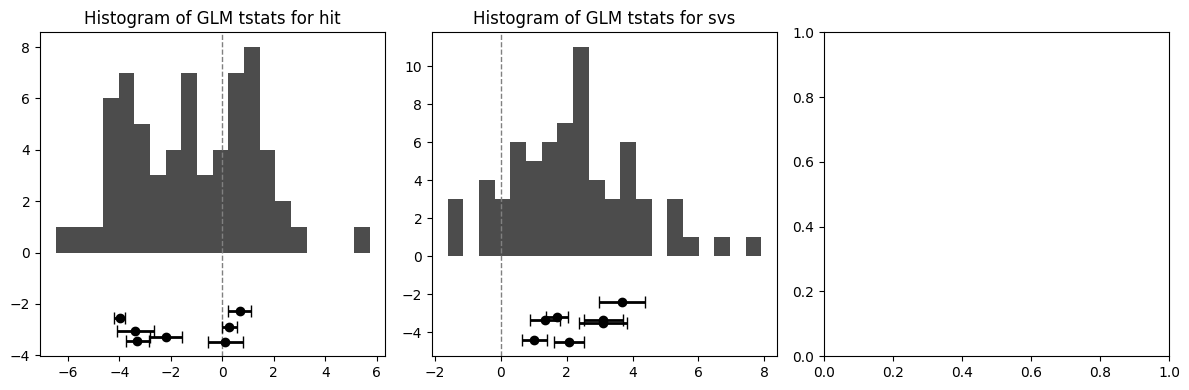

In [20]:
#plot histogram of x_values and y_values
T_or_coeff = 'tstats'
x_val = 'hit'
y_val = 'svs'
hit_period = 'resp'
x_values = hit_results[T_or_coeff][:, hit_bl_bin_ind, hit_results['regressors'].index(x_val)]
y_values = switch_results[T_or_coeff][:, switch_bin_ind, switch_results['regressors'].index(y_val)]

fig_hist = plt.figure(figsize=(12, 4))
gs_hist = GridSpec(1, 3, figure=fig_hist)
ax_hist_x = fig_hist.add_subplot(gs_hist[0, 0])
ax_hist_y = fig_hist.add_subplot(gs_hist[0, 1])
ax_hist_z = fig_hist.add_subplot(gs_hist[0, 2])

ax_hist_x.hist(x_values, bins=20, color='k', alpha=0.7)
ax_hist_x.set_title(f'Histogram of GLM {T_or_coeff} for {x_val}')
ax_hist_x.axvline(0, color='gray', linestyle='--', lw=1)
# add animal-wise mean and standard error as vertical line and shaded area
for ani_ind, ani in enumerate(np.array(hit_ani_results['ani_list'])):
    ani_inds = [i for i, x in enumerate(hit_results['session_list']) if session_dirs(x)['aniID'] == ani]
    ani_x_values = x_values[ani_inds]
    y_value = 2*(np.random.rand()-0.5) - 3
    ax_hist_x.errorbar(
        np.mean(ani_x_values),
        y_value,
        xerr=np.std(ani_x_values) / np.sqrt(len(ani_x_values)),
        fmt='o',    
        color='k',
        ecolor='k',
        elinewidth=2,
        capsize=4,
        markersize=6
    )

ax_hist_y.hist(y_values, bins=20, color='k', alpha=0.7)
ax_hist_y.set_title(f'Histogram of GLM {T_or_coeff} for {y_val}')
ax_hist_y.axvline(0, color='gray', linestyle='--', lw=1)
for ani_ind, ani in enumerate(np.array(switch_ani_results['ani_list'])):
    ani_inds = [i for i, x in enumerate(switch_results['session_list']) if session_dirs(x)['aniID'] == ani]
    ani_y_values = y_values[ani_inds]
    y_value = 3*(np.random.rand()-0.5) - 3
    ax_hist_y.errorbar(
        np.mean(ani_y_values),
        y_value,
        xerr=np.std(ani_y_values) / np.sqrt(len(ani_y_values)),
        fmt='o',    
        color='k',
        ecolor='k',
        elinewidth=2,
        capsize=4,
        markersize=6
    )

plt.tight_layout()  
fig_hist.savefig(os.path.join(save_dir, f'histogram_hit_svs.svg'))

# Export to csv for comparison with ephys data

In [21]:
scatter_data = pd.DataFrame({
    'session': np.array(common_sessions),
    f'{T_or_coeff}_{x_val}': x_values[hit_session_inds],
    # f'{T_or_coeff}_{x_val}_response': x_values_response,
    f'{T_or_coeff}_{y_val}': y_values[switch_session_inds]
})
curr_save_dr = os.path.join(target_folder, 'compare_params')
scatter_data.to_csv(os.path.join(curr_save_dr, f'scatter_data_hit_svs.csv'), index=False)

# G vs Iso peak changes

In [4]:
# Port of `peak_compare_` from
# AllenNeuralDynamics/aind_su_etal_2022_conversion/notebooks/photometry_behavior.ipynb.
#
# For every session in session_list, computes go-cue-aligned mean traces of the
# G and Iso z-scored signals, and derives:
#   response_G          = max(post-goCue mean) − mean(pre-goCue mean)   [respond trials]
#   response_Iso        = same for Iso                                   [respond trials]
#   response_G_mean     = mean(post) − mean(pre) for respond trials      [G]
#   response_Iso_mean   = same for Iso                                   [respond trials]
#   response_diff_G     = response_G(respond) − response_G(ignore)
#   response_diff_Iso   = response_Iso(respond) − response_Iso(ignore)
#   go_resp_G           = ±100 ms window mean difference (all trials, wider window)
#
# Session schema differences vs reference:
#   respond = animal_response != 2  (no CSplus/CSminus distinction here)
#   time axis in seconds, not ms (align_signal_to_events takes seconds)

_g_channel = 'G_tri-exp'
_iso_channel = 'Iso_tri-exp'
_region = 'PL'
_pre_win = 1.0
_post_win = 0.5
_step_size = 0.1
_window_size = 0.3


def peak_compare_(session):
    signal = get_FP_data(session, tar_channels=[(_region, _g_channel), (_region, _iso_channel)])
    if signal is None or _g_channel not in signal or _iso_channel not in signal:
        raise RuntimeError(f'{session}: FP channels not available')
    beh = get_session_tbl(session)

    sig_iso = zscore(signal[_iso_channel][_region])
    sig_G   = zscore(signal[_g_channel][_region])
    t_beh   = np.asarray(signal['time_in_beh'])

    goCue = beh['goCue_start_time'].values
    response_mask = beh['animal_response'].values != 2
    response_time = goCue[response_mask]
    miss_time     = goCue[~response_mask]

    _, psth_iso_resp, time_bins, _ = align_signal_to_events(
        sig_iso, t_beh, response_time,
        pre_event_time=_pre_win, post_event_time=_post_win,
        step_size=_step_size, window_size=_window_size,
    )
    _, psth_G_resp, _, _ = align_signal_to_events(
        sig_G, t_beh, response_time,
        pre_event_time=_pre_win, post_event_time=_post_win,
        step_size=_step_size, window_size=_window_size,
    )
    post = time_bins >= 0
    pre  = time_bins < 0

    response_G        = np.nanmax(psth_G_resp[post])   - np.nanmean(psth_G_resp[pre])
    response_G_mean   = np.nanmean(psth_G_resp[post])  - np.nanmean(psth_G_resp[pre])
    response_Iso      = np.nanmax(psth_iso_resp[post]) - np.nanmean(psth_iso_resp[pre])
    response_Iso_mean = np.nanmean(psth_iso_resp[post]) - np.nanmean(psth_iso_resp[pre])

    if len(miss_time) >= 5:
        _, psth_iso_miss, _, _ = align_signal_to_events(
            sig_iso, t_beh, miss_time,
            pre_event_time=_pre_win, post_event_time=_post_win,
            step_size=_step_size, window_size=_window_size,
        )
        _, psth_G_miss, _, _ = align_signal_to_events(
            sig_G, t_beh, miss_time,
            pre_event_time=_pre_win, post_event_time=_post_win,
            step_size=_step_size, window_size=_window_size,
        )
        response_diff_G = (
            (np.nanmax(psth_G_resp[post]) - np.nanmean(psth_G_resp[pre]))
            - (np.nanmax(psth_G_miss[post]) - np.nanmean(psth_G_miss[pre]))
        )
        response_diff_Iso = (
            (np.nanmax(psth_iso_resp[post]) - np.nanmean(psth_iso_resp[pre]))
            - (np.nanmax(psth_iso_miss[post]) - np.nanmean(psth_iso_miss[pre]))
        )
    else:
        response_diff_G = np.nan
        response_diff_Iso = np.nan

    # go-cue response on ALL trials with a wider window (±1 s), mean-in-window difference
    _, mean_psth, wide_t, _ = align_signal_to_events(
        sig_G, t_beh, goCue,
        pre_event_time=1.0, post_event_time=1.0,
        step_size=0.1, window_size=0.2,
    )
    go_resp_G = np.nanmean(mean_psth[wide_t > 0.1]) - np.nanmean(mean_psth[wide_t < -0.1])

    return session, response_diff_G, response_diff_Iso, go_resp_G, response_G, response_Iso, response_G_mean, response_Iso_mean


def _peak_compare_safe(session):
    """Wrapper for parallel execution: returns (session, tuple) or (session, None) on failure."""
    try:
        return session, peak_compare_(session)
    except Exception as e:
        print(f'Error processing session {session}: {e}')
        return session, None


In [5]:
# --- run across all photometry sessions IN PARALLEL ---
_par_results = Parallel(n_jobs=-1)(delayed(_peak_compare_safe)(s) for s in session_list)

In [8]:

response_diff_G_all = []
response_diff_Iso_all = []
thresh_Gs = []
response_Gs = []
response_Isos = []
response_Gs_mean = []
response_Isos_mean = []
new_sessions_list = []
for _session, _res in _par_results:
    if _res is None:
        continue
    _, _dG, _dIso, _thr, _rG, _rIso, _rGm, _rIm = _res
    new_sessions_list.append(_session)
    response_diff_G_all.append(_dG)
    response_diff_Iso_all.append(_dIso)
    thresh_Gs.append(_thr)
    response_Gs.append(_rG)
    response_Isos.append(_rIso)
    response_Gs_mean.append(_rGm)
    response_Isos_mean.append(_rIm)

new_sessions_list = np.array(new_sessions_list)
response_diff_G_all = np.array(response_diff_G_all)
response_diff_Iso_all = np.array(response_diff_Iso_all)
thresh_Gs   = np.array(thresh_Gs)
response_Gs = np.array(response_Gs)
response_Isos = np.array(response_Isos)
response_Gs_mean = np.array(response_Gs_mean)
response_Isos_mean = np.array(response_Isos_mean)



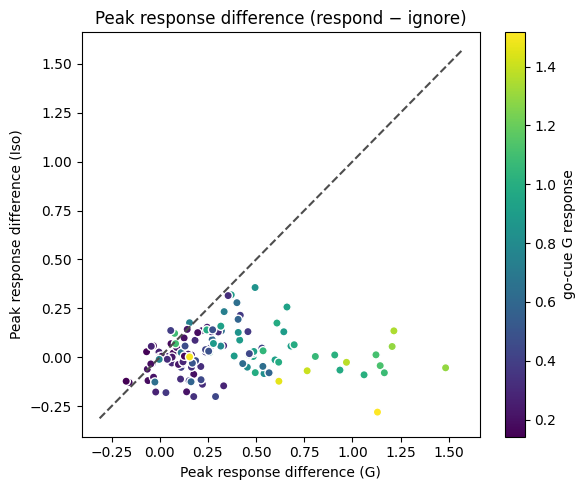

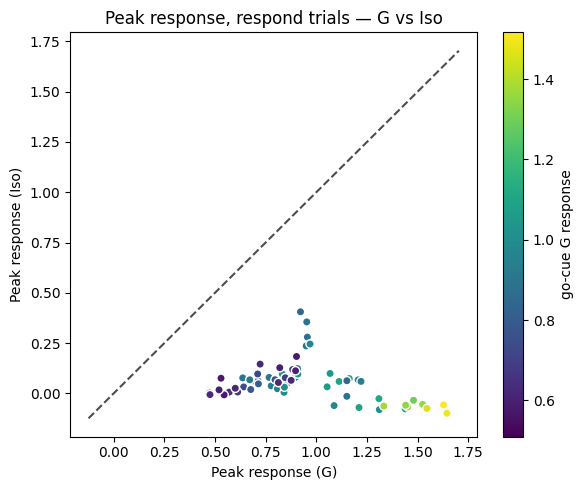

In [9]:

# --- Panel 1: response-diff (hit − miss), colored by go-cue G response ---
fig1, ax1 = plt.subplots(figsize=(6, 5))
_mask_diff = (thresh_Gs > 0.1) & np.isfinite(response_diff_G_all) & np.isfinite(response_diff_Iso_all)
sc1 = ax1.scatter(
    response_diff_G_all[_mask_diff],
    response_diff_Iso_all[_mask_diff],
    c=thresh_Gs[_mask_diff],
    cmap='viridis',
    edgecolors='w',
)
ax1.set_xlabel('Peak response difference (G)')
ax1.set_ylabel('Peak response difference (Iso)')
ax1.set_title('Peak response difference (respond − ignore)')
plt.colorbar(sc1, ax=ax1, label='go-cue G response')
_lo1 = float(np.nanmin([ax1.get_xlim()[0], ax1.get_ylim()[0]]))
_hi1 = float(np.nanmax([ax1.get_xlim()[1], ax1.get_ylim()[1]]))
ax1.plot([_lo1, _hi1], [_lo1, _hi1], ls='--', c='0.3')
plt.tight_layout()
# save_panels(fig1, save_dir, 'peak_compare_G_vs_Iso_hit_minus_miss', ['FigureS17g_left'], exts=('pdf',))
# save_panel_csv(
#     columns_to_df(
#         session=all_sessions[_mask_diff],
#         response_diff_G=response_diff_G_all[_mask_diff],
#         response_diff_Iso=response_diff_Iso_all[_mask_diff],
#         go_cue_G_response=thresh_Gs[_mask_diff],
#     ),
#     save_dir, 'peak_compare_G_vs_Iso_hit_minus_miss', ['FigureS17g_left'],
# )

# --- Panel 2: absolute peak response (respond trials), colored by go-cue G response ---
fig2, ax2 = plt.subplots(figsize=(6, 5))
_mask_abs = (thresh_Gs > 0.5) & np.isfinite(response_Gs) & np.isfinite(response_Isos)
sc2 = ax2.scatter(
    response_Gs[_mask_abs],
    response_Isos[_mask_abs],
    c=thresh_Gs[_mask_abs],
    cmap='viridis',
    edgecolors='w',
)
ax2.set_xlabel('Peak response (G)')
ax2.set_ylabel('Peak response (Iso)')
ax2.set_title('Peak response, respond trials — G vs Iso')
plt.colorbar(sc2, ax=ax2, label='go-cue G response')
_lo2 = float(np.nanmin([ax2.get_xlim()[0], ax2.get_ylim()[0], 0]))
_hi2 = float(np.nanmax([ax2.get_xlim()[1], ax2.get_ylim()[1]]))
ax2.plot([_lo2, _hi2], [_lo2, _hi2], ls='--', c='0.3')
plt.tight_layout()
# save_panels(fig2, save_dir, 'peak_compare_G_vs_Iso_respond', ['FigureS17g_right'], exts=('pdf',))
# save_panel_csv(
#     columns_to_df(
#         session=all_sessions[_mask_abs],
#         response_G=response_Gs[_mask_abs],
#         response_Iso=response_Isos[_mask_abs],
#         go_cue_G_response=thresh_Gs[_mask_abs],
#     ),
#     save_dir, 'peak_compare_G_vs_Iso_respond', ['FigureS17g_right'],
# )

plt.show()
##FigureS17g_left##
##FigureS17g_right##


['/root/capsule/scratch/results/manuscript/figures/F_photometry/tuning&psth/FigureS17g_peak_compare_G_vs_Iso_mean.csv']

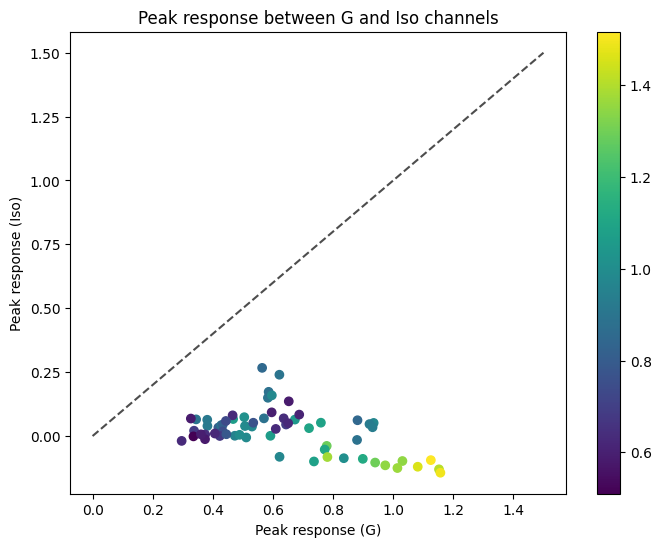

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.array(thresh_Gs) > 0.5
im = ax.scatter(np.array(response_Gs_mean)[mask], np.array(response_Isos_mean)[mask], c=np.array(thresh_Gs)[mask], cmap='viridis')
ax.set_xlabel('Peak response (G)')
ax.set_ylabel('Peak response (Iso)')
ax.set_title('Peak response between G and Iso channels')

# colorbar
cbar = plt.colorbar(im, ax=ax)
# diagonal line
ax.plot([0, 1.5], [0, 1.5], ls="--", c=".3")
# panel
panel = 'FigureS17g'

# save figure + CSV
_name = 'peak_compare_G_vs_Iso_mean'
save_panels(fig, save_dir, _name, [panel], exts=('pdf',))
save_panel_csv(
    columns_to_df(
        session=np.asarray(new_sessions_list)[mask],
        response_G_mean=np.asarray(response_Gs_mean)[mask],
        response_Iso_mean=np.asarray(response_Isos_mean)[mask],
        go_cue_G_response=np.asarray(thresh_Gs)[mask],
    ),
    save_dir, _name, [panel],
)
##FigureS17g##